# 📊 Análise Exploratória do Desempenho de Estudantes em Exames

## 🎯 Objetivos da Análise

- Analisar de que forma fatores socioeconômicos influenciam o desempenho dos estudantes.
- Verificar se a realização de curso preparatório está associada a melhores resultados.
- Identificar padrões de desempenho entre as disciplinas de matemática, leitura e escrita.
- Investigar a relação entre gênero e desempenho acadêmico.

**Dataset:** Students Performance in Exams — Kaggle  
**Total de registros:** 1000 estudantes

In [1]:
# Importando as bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configurações visuais
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("✅ Bibliotecas importadas com sucesso!")

✅ Bibliotecas importadas com sucesso!


In [2]:
# Carregando o dataset
df = pd.read_csv('files/StudentsPerformance.csv')

print("✅ Dataset carregado com sucesso!")
print(f"📏 Dimensões: {df.shape}")
print(f"📋 Colunas: {list(df.columns)}")
df.head()

✅ Dataset carregado com sucesso!
📏 Dimensões: (1000, 8)
📋 Colunas: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## 1. 🔍 Exploração Inicial dos Dados

In [3]:
print("📋 Tipos de dados e valores nulos:")
print("=" * 45)
print(df.info())
print()
print("❓ Valores nulos por coluna:")
print(df.isnull().sum())

📋 Tipos de dados e valores nulos:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB
None

❓ Valores nulos por coluna:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0


In [4]:
print("📊 Estatísticas das notas:")
df[['math score', 'reading score', 'writing score']].describe().round(2)

📊 Estatísticas das notas:


,math score,reading score,writing score
count,1000.00,1000.00,1000.00
mean,66.09,69.17,68.05
std,15.16,14.60,15.20
min,0.00,17.00,10.00
25%,57.00,59.00,57.75
50%,66.00,70.00,69.00
75%,77.00,79.00,79.00
max,100.00,100.00,100.00


In [5]:
colunas_categoricas = ['gender', 'race/ethnicity', 
                       'parental level of education', 
                       'lunch', 'test preparation course']

print("🔎 Valores únicos por coluna categórica:")
print("=" * 45)
for coluna in colunas_categoricas:
    valores = df[coluna].value_counts()
    print(f"\n📌 {coluna}:")
    print(valores)

🔎 Valores únicos por coluna categórica:

📌 gender:
gender
female    518
male      482
Name: count, dtype: int64

📌 race/ethnicity:
race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

📌 parental level of education:
parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

📌 lunch:
lunch
standard        645
free/reduced    355
Name: count, dtype: int64

📌 test preparation course:
test preparation course
none         642
completed    358
Name: count, dtype: int64


## 2. 🧹 Limpeza dos Dados

O dataset não possui valores nulos, portanto a limpeza será focada em:
- Renomear colunas para facilitar o uso no código
- Criar coluna de média geral dos estudantes

In [6]:
# Renomeando as colunas (removendo espaços e caracteres especiais)
df.columns = ['gender', 'ethnicity', 'parent_education', 
              'lunch', 'test_prep', 'math', 'reading', 'writing']

# Criando coluna de média geral
df['average'] = (df['math'] + df['reading'] + df['writing']) / 3
df['average'] = df['average'].round(2)

print("✅ Colunas renomeadas e média calculada.")
print(f"\n📋 Novas colunas: {list(df.columns)}")
print(f"\n📊 Prévia com a nova coluna:")
df.head()

✅ Colunas renomeadas e média calculada.

📋 Novas colunas: ['gender', 'ethnicity', 'parent_education', 'lunch', 'test_prep', 'math', 'reading', 'writing', 'average']

📊 Prévia com a nova coluna:


,gender,ethnicity,parent_education,lunch,test_prep,math,reading,writing,average
0,female,group B,bachelor's degree,standard,none,72,72,74,72.67
1,female,group C,some college,standard,completed,69,90,88,82.33
2,female,group B,master's degree,standard,none,90,95,93,92.67
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.33
4,male,group C,some college,standard,none,76,78,75,76.33


## 3. 👥 Visão Geral do Dataset

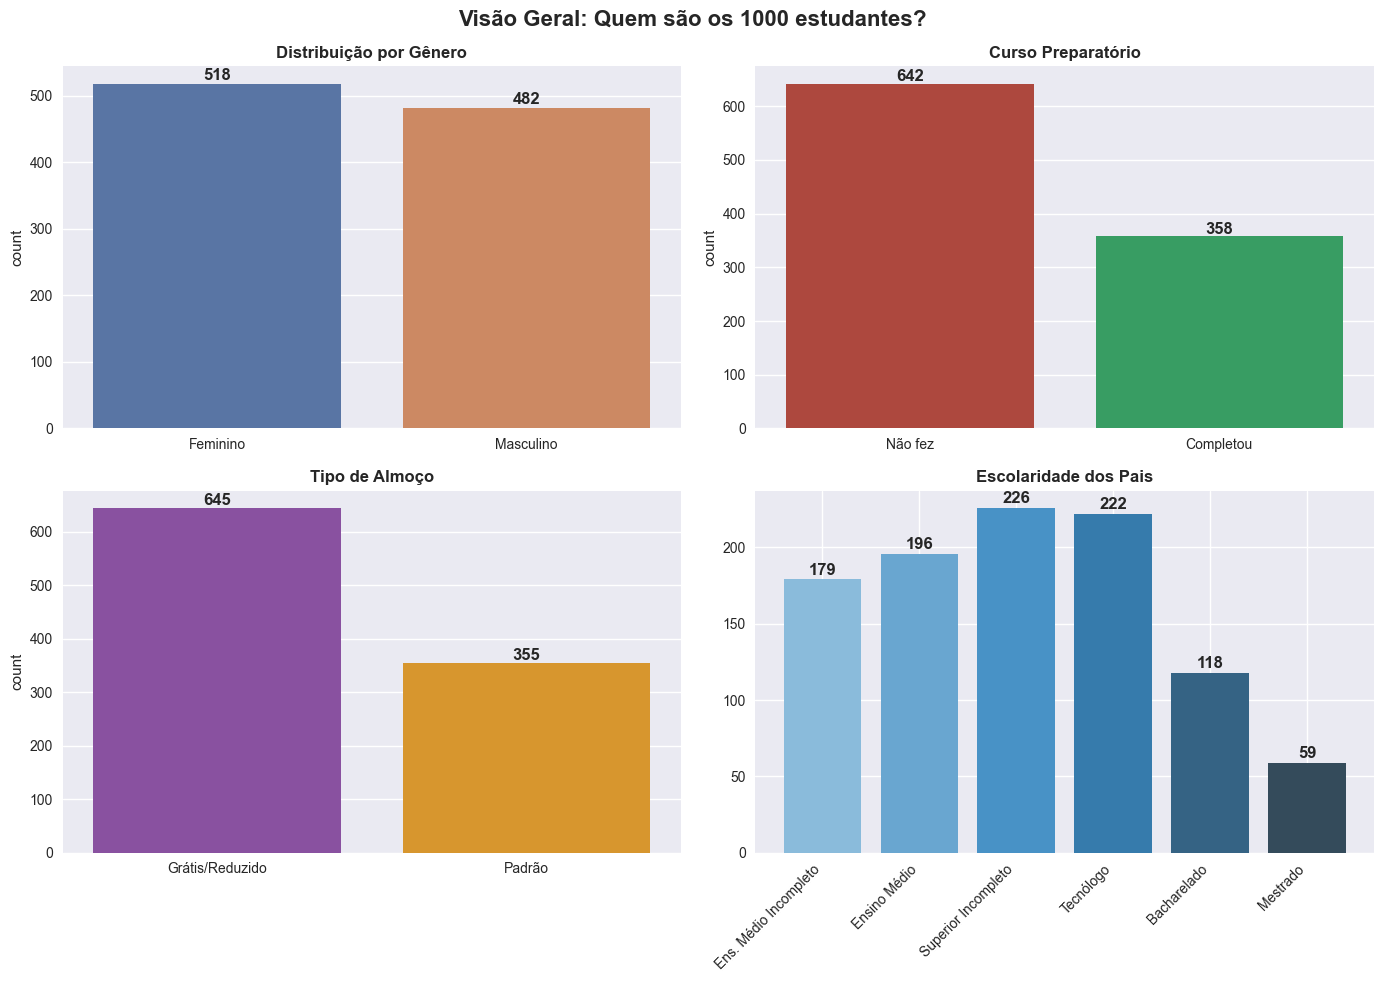

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gênero
sns.countplot(x='gender', data=df, hue='gender',
              palette=['#4C72B0','#DD8452'], legend=False, ax=axes[0,0])
axes[0,0].set_title('Distribuição por Gênero', fontweight='bold')
axes[0,0].set_xticks([0, 1])
axes[0,0].set_xticklabels(['Feminino','Masculino'])
axes[0,0].set_xlabel('')
for p in axes[0,0].patches:
    axes[0,0].annotate(f'{int(p.get_height())}',
                       (p.get_x()+p.get_width()/2, p.get_height()+5),
                       ha='center', fontweight='bold')

# Curso preparatório
sns.countplot(x='test_prep', data=df, hue='test_prep',
              palette=['#c0392b','#27ae60'], legend=False, ax=axes[0,1])
axes[0,1].set_title('Curso Preparatório', fontweight='bold')
axes[0,1].set_xticks([0, 1])
axes[0,1].set_xticklabels(['Não fez','Completou'])
axes[0,1].set_xlabel('')
for p in axes[0,1].patches:
    axes[0,1].annotate(f'{int(p.get_height())}',
                       (p.get_x()+p.get_width()/2, p.get_height()+5),
                       ha='center', fontweight='bold')

# Tipo de almoço
sns.countplot(x='lunch', data=df, hue='lunch',
              palette=['#8e44ad','#f39c12'], legend=False, ax=axes[1,0])
axes[1,0].set_title('Tipo de Almoço', fontweight='bold')
axes[1,0].set_xticks([0, 1])
axes[1,0].set_xticklabels(['Grátis/Reduzido','Padrão'])
axes[1,0].set_xlabel('')
for p in axes[1,0].patches:
    axes[1,0].annotate(f'{int(p.get_height())}',
                       (p.get_x()+p.get_width()/2, p.get_height()+5),
                       ha='center', fontweight='bold')

# Escolaridade dos pais
ordem = ['some high school','high school','some college',
         "associate's degree","bachelor's degree","master's degree"]

# Nomenclatura
rotulos = ['Ens. Médio Incompleto', 'Ensino Médio', 'Superior Incompleto',
           'Tecnólogo', 'Bacharelado', 'Mestrado']

contagens = [df[df['parent_education']==n].shape[0] for n in ordem]

axes[1,1].bar(range(len(ordem)), contagens,
              color=sns.color_palette('Blues_d', len(ordem)))
axes[1,1].set_title('Escolaridade dos Pais', fontweight='bold')
axes[1,1].set_xticks(range(len(ordem)))

axes[1,1].set_xticklabels(rotulos, fontsize=10, rotation=45, ha='right')

for i, v in enumerate(contagens):
    axes[1,1].text(i, v+3, str(v), ha='center', fontweight='bold')

fig.suptitle('Visão Geral: Quem são os 1000 estudantes?',
             fontsize=16, fontweight='bold')

# O tight_layout ajusta os espaços para os rótulos rotacionados não cortarem
plt.tight_layout()
plt.show()

## 4. 📊 Análise Exploratória e Visualizações

### 4.1 🔍 Pergunta 1: O gênero influencia o desempenho?

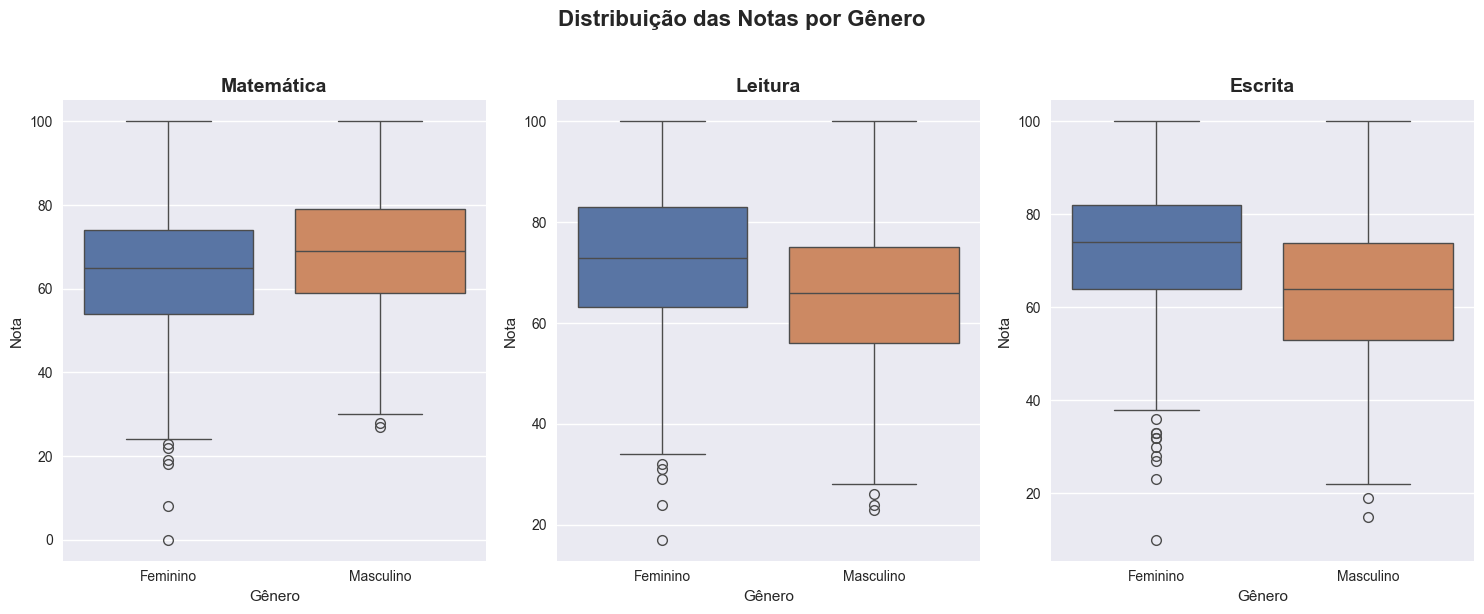

Médias por Gênero:
         math  reading  writing  average
gender                                  
female  63.63    72.61    72.47    69.57
male    68.73    65.47    63.31    65.84


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

disciplinas = ['math', 'reading', 'writing']
titulos = ['Matemática', 'Leitura', 'Escrita']
cores = ['#4C72B0', '#DD8452']

for i, (disciplina, titulo) in enumerate(zip(disciplinas, titulos)):
    sns.boxplot(x='gender', y=disciplina, data=df,
                hue='gender', palette=cores, legend=False, ax=axes[i])
    axes[i].set_title(titulo, fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Gênero')
    axes[i].set_ylabel('Nota')
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Feminino', 'Masculino'])

fig.suptitle('Distribuição das Notas por Gênero',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Médias por gênero
print("Médias por Gênero:")
print("=" * 40)
print(df.groupby('gender')[['math', 'reading', 'writing', 'average']].mean().round(2))

#### 💡 Conclusão — Pergunta 1

O gênero influencia o desempenho de forma diferente dependendo da disciplina:

- **Matemática:** Masculino se destaca (68,73 vs. 63,63)
- **Leitura:** Feminino se destaca (72,61 vs. 65,47)
- **Escrita:** Feminino tem a maior diferença (72,47 vs. 63,31 — 9 pontos)
- **Média geral:** Feminino lidera (69,57 vs. 65,84)

Os resultados indicam diferenças de desempenho entre os gêneros a depender da disciplina analisada.

### 4.2 🔍 Pergunta 2: O curso preparatório faz diferença?

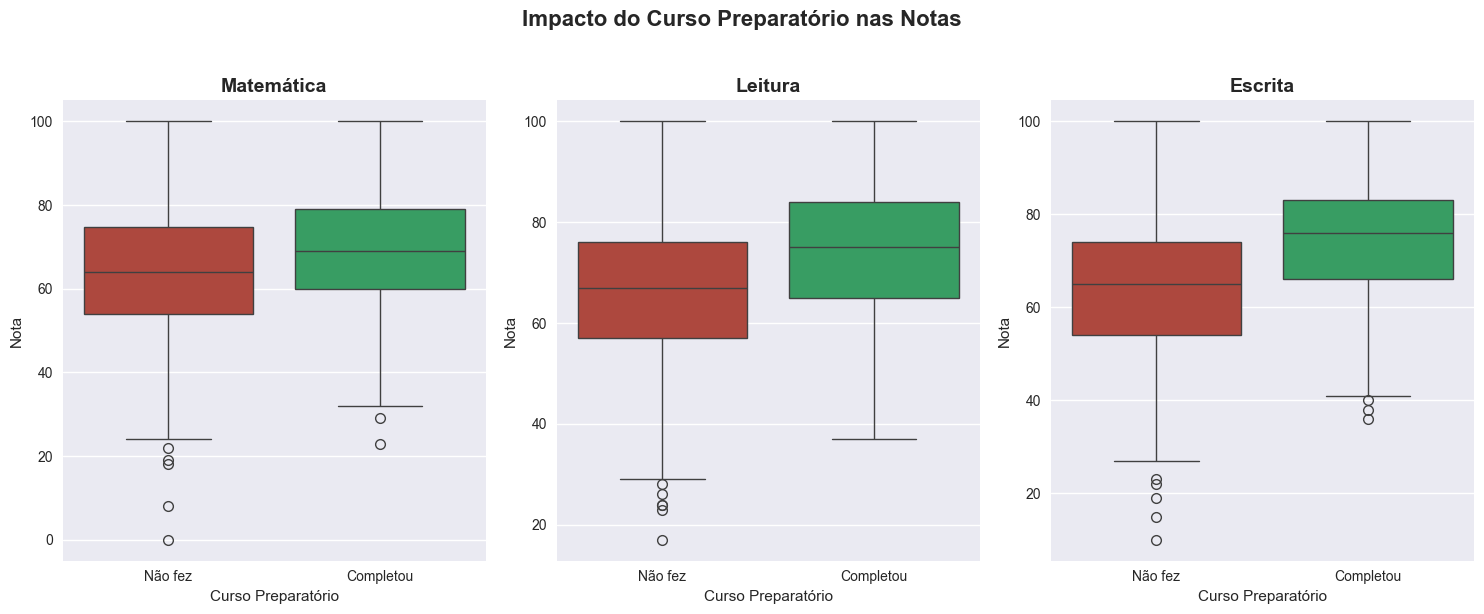

Médias por Curso Preparatório:
            math  reading  writing  average
test_prep                                  
completed  69.70    73.89    74.42    72.67
none       64.08    66.53    64.50    65.04

Diferença (Completou - Não fez):
math       5.62
reading    7.36
writing    9.92
average    7.63
dtype: float64


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

disciplinas = ['math', 'reading', 'writing']
titulos = ['Matemática', 'Leitura', 'Escrita']
cores = ['#c0392b', '#27ae60']

for i, (disciplina, titulo) in enumerate(zip(disciplinas, titulos)):
    sns.boxplot(x='test_prep', y=disciplina, data=df,
                hue='test_prep', palette=cores, legend=False, ax=axes[i])
    axes[i].set_title(titulo, fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Curso Preparatório')
    axes[i].set_ylabel('Nota')
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Não fez', 'Completou'])

fig.suptitle('Impacto do Curso Preparatório nas Notas',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Médias por curso preparatório
print("Médias por Curso Preparatório:")
print("=" * 45)
print(df.groupby('test_prep')[['math', 'reading', 'writing', 'average']].mean().round(2))

# Diferença entre os grupos
print("\nDiferença (Completou - Não fez):")
print("=" * 45)
medias = df.groupby('test_prep')[['math', 'reading', 'writing', 'average']].mean().round(2)
diferenca = medias.loc['completed'] - medias.loc['none']
print(diferenca.round(2))

#### 💡 Conclusão — Pergunta 2

O curso preparatório demonstrou impacto positivo em todas as disciplinas:

| Disciplina | Sem curso | Com curso | Diferença |
|------------|-----------|-----------|-----------|
| Matemática | 64,08 | 69,70 | +5,62 |
| Leitura | 66,53 | 73,89 | +7,36 |
| Escrita | 64,50 | 74,42 | +9,92 |
| **Média geral** | **65,04** | **72,67** | **+7,63** |

A escrita foi a disciplina com maior ganho (+9,92 pontos).
Alunos que completaram o curso tiveram, em média, **7,63 pontos a mais**
do que os que não fizeram — uma diferença considerável e consistente.

### 4.3 🔍 Pergunta 3: A escolaridade dos pais influencia o desempenho dos estudantes?

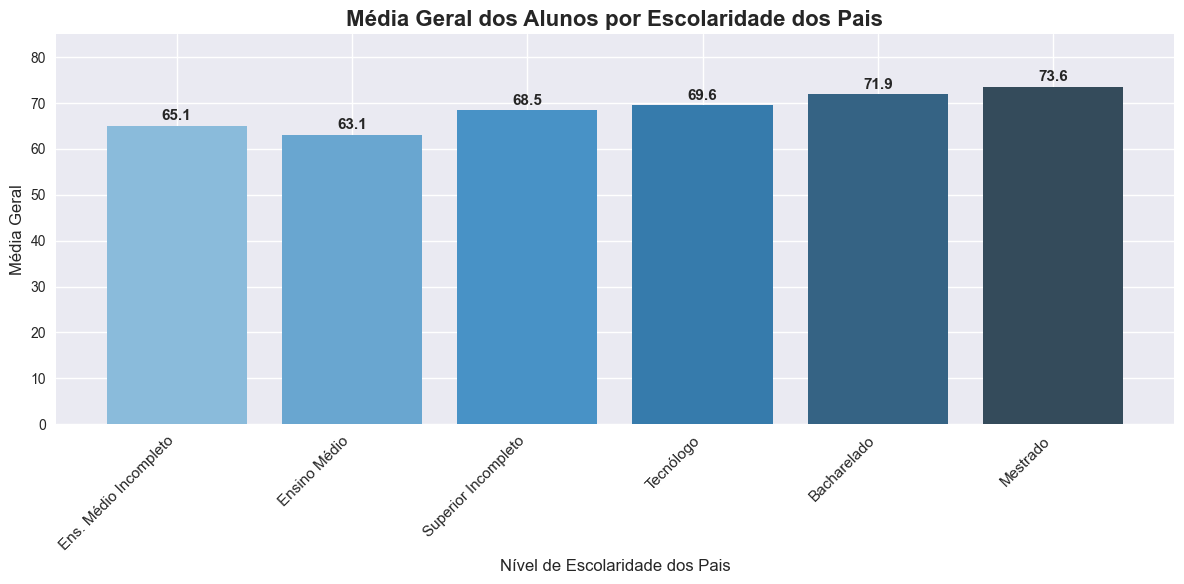

Médias por Nível de Escolaridade dos Pais:
Ens. Médio Incompleto     → 65.11
Ensino Médio              → 63.10
Superior Incompleto       → 68.48
Tecnólogo                 → 69.57
Bacharelado               → 71.92
Mestrado                  → 73.60


In [10]:
# Definindo a ordem lógica dos níveis de educação (mantendo o inglês para o groupby funcionar)
ordem_educacao = [
    'some high school',
    'high school',
    'some college',
    "associate's degree",
    "bachelor's degree",
    "master's degree"
]

# Nomenclatura profissional em português
rotulos_pt = [
    'Ens. Médio Incompleto',
    'Ensino Médio',
    'Superior Incompleto',
    'Tecnólogo',
    'Bacharelado',
    'Mestrado'
]

# Calculando a média geral por nível de educação dos pais
medias_educacao = df.groupby('parent_education')['average'].mean().round(2)
medias_educacao = medias_educacao.reindex(ordem_educacao)

# Gráfico
plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(ordem_educacao)), medias_educacao.values,
               color=sns.color_palette('Blues_d', len(ordem_educacao)))

# Rótulos nas barras
for i, valor in enumerate(medias_educacao.values):
    plt.text(i, valor + 0.5, f'{valor:.1f}', ha='center', 
             va='bottom', fontweight='bold', fontsize=11)

# Aplicando a rotação de 45 graus e alinhamento à direita
plt.xticks(range(len(ordem_educacao)), rotulos_pt,
           fontsize=11, rotation=45, ha='right')

plt.title('Média Geral dos Alunos por Escolaridade dos Pais',
          fontsize=16, fontweight='bold')
plt.xlabel('Nível de Escolaridade dos Pais', fontsize=12)
plt.ylabel('Média Geral', fontsize=12)
plt.ylim(0, 85)

plt.tight_layout()
plt.show()

# Tabela de médias impressa no console (agora em português)
print("Médias por Nível de Escolaridade dos Pais:")
print("=" * 50)
for nivel, media in zip(rotulos_pt, medias_educacao.values):
    print(f"{nivel:<25} → {media:.2f}")

#### 💡 Conclusão — Pergunta 3

Observa-se uma tendência de aumento no desempenho dos estudantes à medida que se eleva o nível de escolaridade dos pais.

| Escolaridade dos Pais | Média dos Filhos |
|-----------------------|------------------|
| Ens. Médio Incompleto | 65,11 |
| Ensino Médio | 63,10 |
| Superior Incompleto | 68,48 |
| Tecnólogo | 69,57 |
| Bacharelado | 71,92 |
| Mestrado | 73,60 |

A tendência é crescente a partir do ensino médio — filhos de pais
com mestrado tiveram média **10,5 pontos maior** do que filhos de
pais com apenas ensino médio completo. Isso sugere que o capital
educacional da família influencia diretamente o desempenho escolar.

### 4.4 🔍 Pergunta 4: O tipo de alimentação escolar, utilizado como indicador socioeconômico, está associado ao desempenho dos estudantes?

> O tipo de almoço nos EUA foi considerado um indicador socioeconômico:
> alunos com `free/reduced` geralmente pertencem a famílias de menor renda.

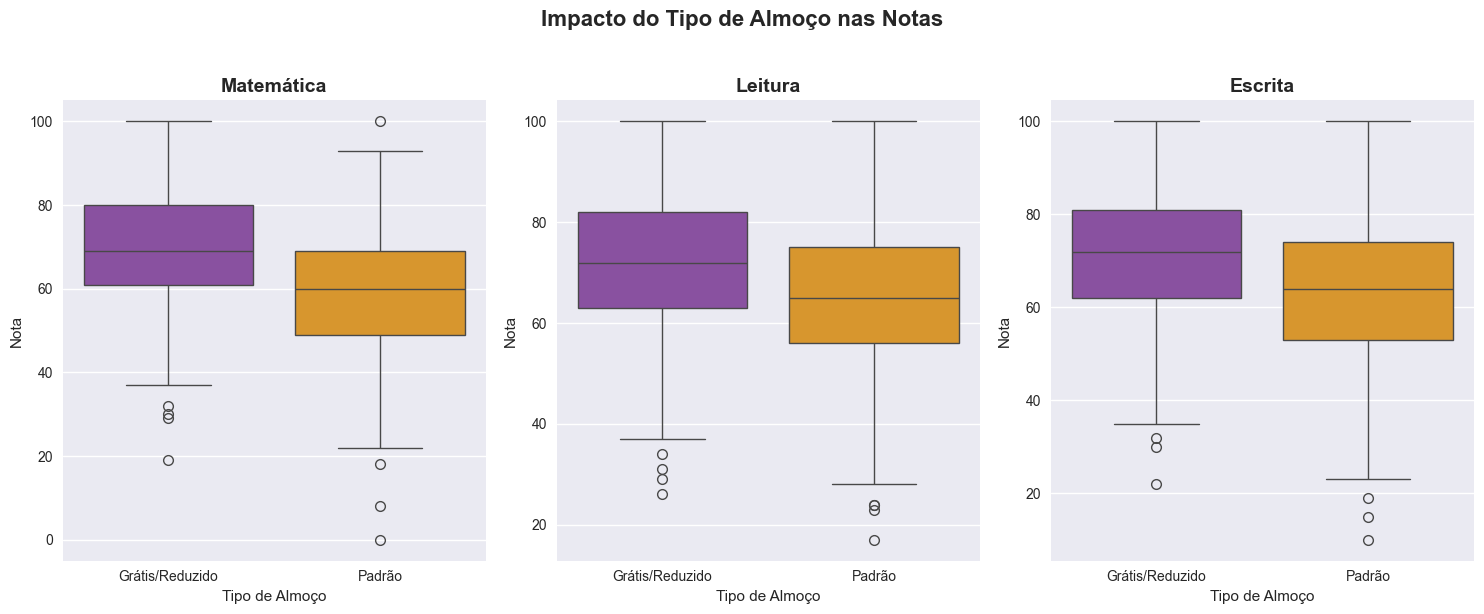

Médias por Tipo de Almoço:
               math  reading  writing  average
lunch                                         
free/reduced  58.92    64.65    63.02    62.20
standard      70.03    71.65    70.82    70.84

Diferença (Padrão - Grátis/Reduzido):
math       11.11
reading     7.00
writing     7.80
average     8.64
dtype: float64


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

disciplinas = ['math', 'reading', 'writing']
titulos = ['Matemática', 'Leitura', 'Escrita']
cores = ['#8e44ad', '#f39c12']

for i, (disciplina, titulo) in enumerate(zip(disciplinas, titulos)):
    sns.boxplot(x='lunch', y=disciplina, data=df,
                hue='lunch', palette=cores, legend=False, ax=axes[i])
    axes[i].set_title(titulo, fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Tipo de Almoço')
    axes[i].set_ylabel('Nota')
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Grátis/Reduzido', 'Padrão'])

fig.suptitle('Impacto do Tipo de Almoço nas Notas',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Médias e diferença
print("Médias por Tipo de Almoço:")
print("=" * 45)
medias = df.groupby('lunch')[['math', 'reading', 'writing', 'average']].mean().round(2)
print(medias)

print("\nDiferença (Padrão - Grátis/Reduzido):")
print("=" * 45)
diferenca = medias.loc['standard'] - medias.loc['free/reduced']
print(diferenca.round(2))

#### 💡 Conclusão — Pergunta 4

Esse resultado sugere que fatores socioeconômicos podem estar associados ao desempenho escolar.

| Disciplina | Grátis/Reduzido | Padrão | Diferença |
|------------|-----------------|--------|-----------|
| Matemática | 58,92 | 70,03 | +11,11 |
| Leitura | 64,65 | 71,65 | +7,00 |
| Escrita | 63,02 | 70,82 | +7,80 |
| **Média geral** | **62,20** | **70,84** | **+8,64** |

Alunos com almoço padrão tiveram, em média, **8,64 pontos a mais**.
Em matemática a diferença chegou a **11 pontos** — a maior encontrada
em toda a análise. Isso reforça que fatores socioeconômicos têm
impacto direto e significativo no desempenho escolar.

### 4.5 🔍 Pergunta 5: Existe correlação entre as três disciplinas?

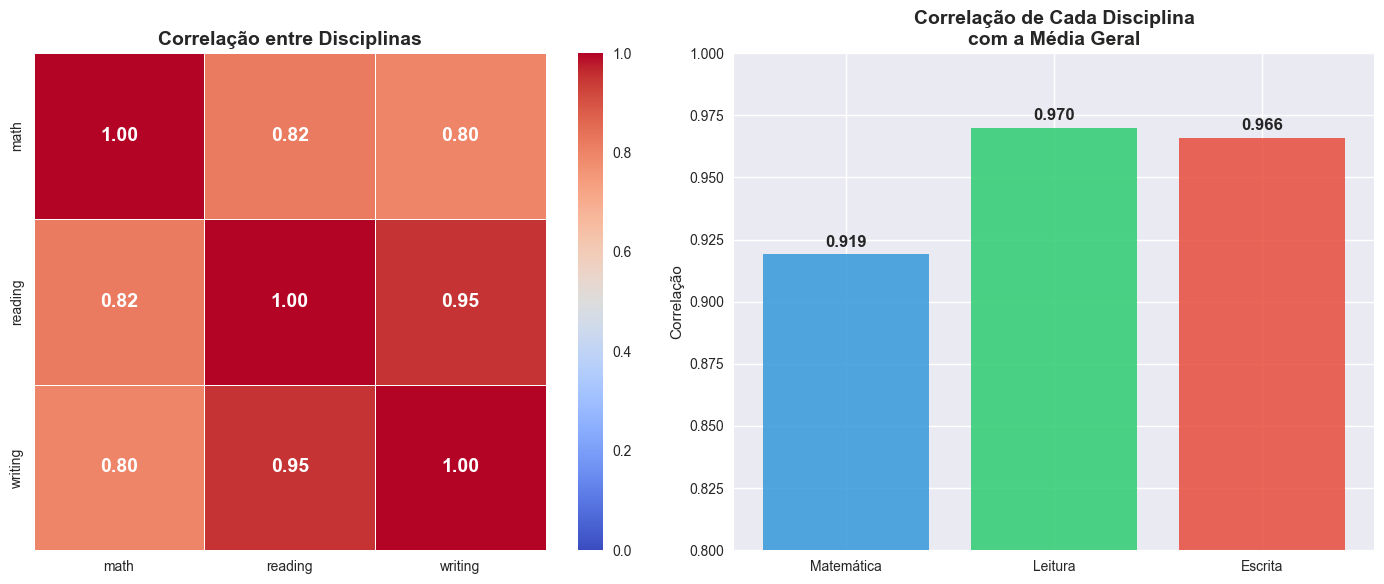

Matriz de Correlação:
         math  reading  writing
math     1.00     0.82     0.80
reading  0.82     1.00     0.95
writing  0.80     0.95     1.00

Correlação de cada disciplina com a média geral:
Matemática   → 0.919
Leitura      → 0.970
Escrita      → 0.966


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Gráfico 1: Heatmap de correlação ---
correlacoes = df[['math', 'reading', 'writing']].corr().round(2)

sns.heatmap(correlacoes, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=axes[0], vmin=0, vmax=1,
            annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_title('Correlação entre Disciplinas', 
                  fontsize=14, fontweight='bold')

# --- Gráfico 2: Barras de correlação com a média ---
disciplinas = ['math', 'reading', 'writing']
nomes = ['Matemática', 'Leitura', 'Escrita']
corr_com_media = [df[d].corr(df['average']).round(3) for d in disciplinas]

bars = axes[1].bar(nomes, corr_com_media,
                   color=['#3498db', '#2ecc71', '#e74c3c'], alpha=0.85)
axes[1].set_title('Correlação de Cada Disciplina\ncom a Média Geral',
                  fontsize=14, fontweight='bold')
axes[1].set_ylabel('Correlação')
axes[1].set_ylim(0.8, 1.0)

for bar, valor in zip(bars, corr_com_media):
    axes[1].text(bar.get_x() + bar.get_width()/2, 
                 bar.get_height() + 0.002,
                 f'{valor:.3f}', ha='center', 
                 va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Tabela de correlações
print("Matriz de Correlação:")
print("=" * 40)
print(correlacoes)
print("\nCorrelação de cada disciplina com a média geral:")
print("=" * 40)
for d, n, c in zip(disciplinas, nomes, corr_com_media):
    print(f"{n:<12} → {c:.3f}")

Gerando Pairplot...


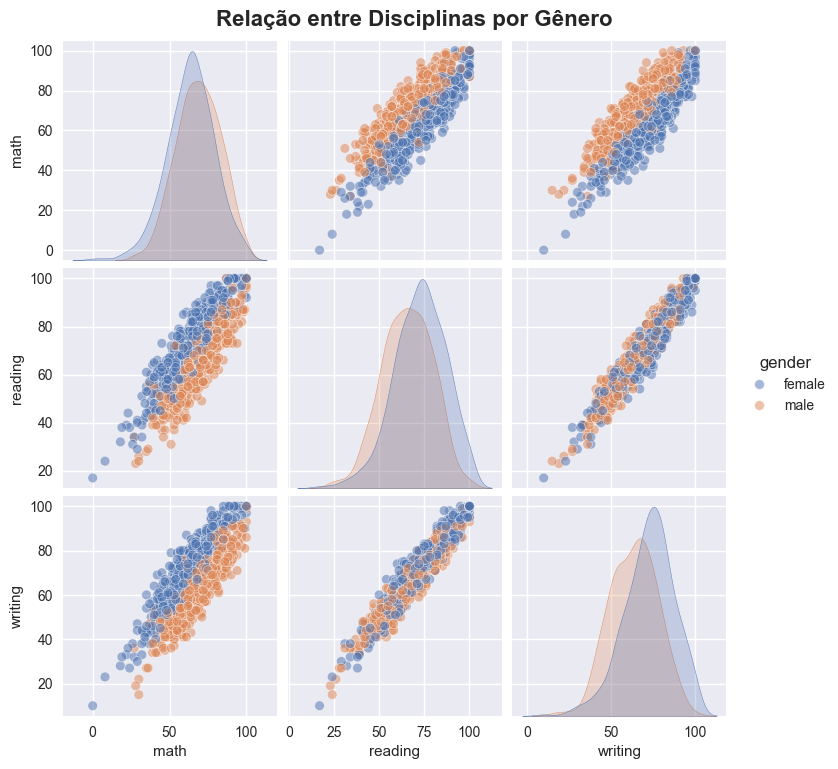

In [13]:
# Pairplot — visão completa das relações entre disciplinas
print("Gerando Pairplot...")

g = sns.pairplot(df[['math', 'reading', 'writing', 'gender']],
                 hue='gender', palette=['#4C72B0', '#DD8452'],
                 diag_kind='kde', plot_kws={'alpha': 0.5})

g.figure.suptitle('Relação entre Disciplinas por Gênero',
                  fontsize=16, fontweight='bold', y=1.02)
plt.show()

#### 💡 Conclusão — Pergunta 5

As três disciplinas apresentam correlação positiva forte entre si:

| Par de Disciplinas | Correlação |
|--------------------|------------|
| Matemática × Leitura | 0,82 |
| Matemática × Escrita | 0,80 |
| Leitura × Escrita | **0,95** |

- Leitura e escrita têm correlação quase perfeita (0,95) — são
  habilidades linguísticas que se desenvolvem juntas
- Matemática, embora correlacionada, é mais independente (0,80~0,82)
- Todas as disciplinas têm correlação acima de 0,91 com a média geral
- O pairplot confirma os padrões de gênero encontrados na Pergunta 1:
  pontos masculinos tendem a subir em matemática, femininos em leitura
  e escrita

---
## 5. 📋 Resumo dos Resultados - Principais Descobertas

In [14]:
print("=" * 55)
print("  RESUMO DOS RESULTADOS: DESEMPENHO DE ESTUDANTES")
print("=" * 55)

print("\nESTATÍSTICAS GERAIS:")
print(f"  Total de estudantes analisados : {len(df)}")
print(f"  Média geral de matemática      : {df['math'].mean():.2f}")
print(f"  Média geral de leitura         : {df['reading'].mean():.2f}")
print(f"  Média geral de escrita         : {df['writing'].mean():.2f}")
print(f"  Média geral combinada          : {df['average'].mean():.2f}")

print("\n1) GÊNERO:")
medias_genero = df.groupby('gender')['average'].mean()
print(f"  Feminino  : {medias_genero['female']:.2f}")
print(f"  Masculino : {medias_genero['male']:.2f}")
print(f"  Feminino lidera na média geral por {(medias_genero['female'] - medias_genero['male']):.2f} pontos")
print(f"  Masculino se destaca em matemática, feminino em leitura e escrita")

print("\n2) CURSO PREPARATÓRIO:")
medias_prep = df.groupby('test_prep')['average'].mean()
diferenca_prep = medias_prep['completed'] - medias_prep['none']
print(f"  Com curso    : {medias_prep['completed']:.2f}")
print(f"  Sem curso    : {medias_prep['none']:.2f}")
print(f"  Diferença    : +{diferenca_prep:.2f} pontos para quem completou")
print(f"  Maior impacto: escrita (+9.92 pontos)")

print("\n3) ESCOLARIDADE DOS PAIS:")
medias_edu = df.groupby('parent_education')['average'].mean()
maior = medias_edu.idxmax()
menor = medias_edu.idxmin()
print(f"  Maior média : {maior} ({medias_edu[maior]:.2f})")
print(f"  Menor média : {menor} ({medias_edu[menor]:.2f})")
print(f"  Diferença   : {(medias_edu[maior] - medias_edu[menor]):.2f} pontos entre extremos")
print(f"  Tendência   : quanto maior a educação dos pais, maior a nota")

print("\n4) FATOR SOCIOECONÔMICO (almoço):")
medias_lunch = df.groupby('lunch')['average'].mean()
diferenca_lunch = medias_lunch['standard'] - medias_lunch['free/reduced']
print(f"  Almoço padrão       : {medias_lunch['standard']:.2f}")
print(f"  Almoço subsidiado   : {medias_lunch['free/reduced']:.2f}")
print(f"  Diferença           : +{diferenca_lunch:.2f} pontos (maior diferença encontrada)")
print(f"  Maior impacto       : matemática (+11.11 pontos)")

print("\n5) CORRELAÇÃO ENTRE DISCIPLINAS:")
print(f"  Leitura x Escrita   : 0.95 (muito forte)")
print(f"  Matemática x Leitura: 0.82 (forte)")
print(f"  Matemática x Escrita: 0.80 (forte)")
print(f"  Quem vai bem em uma disciplina tende a ir bem nas outras")

print("\nCONCLUSÃO FINAL:")
print(f"  O fator socioeconômico (almoço) foi o mais impactante (+8.64)")
print(f"  O curso preparatório é altamente recomendável (+7.63)")
print(f"  A educação dos pais também influencia significativamente")
print(f"  Todos os fatores analisados afetam o desempenho escolar")

  RESUMO DOS RESULTADOS: DESEMPENHO DE ESTUDANTES

ESTATÍSTICAS GERAIS:
  Total de estudantes analisados : 1000
  Média geral de matemática      : 66.09
  Média geral de leitura         : 69.17
  Média geral de escrita         : 68.05
  Média geral combinada          : 67.77

1) GÊNERO:
  Feminino  : 69.57
  Masculino : 65.84
  Feminino lidera na média geral por 3.73 pontos
  Masculino se destaca em matemática, feminino em leitura e escrita

2) CURSO PREPARATÓRIO:
  Com curso    : 72.67
  Sem curso    : 65.04
  Diferença    : +7.63 pontos para quem completou
  Maior impacto: escrita (+9.92 pontos)

3) ESCOLARIDADE DOS PAIS:
  Maior média : master's degree (73.60)
  Menor média : high school (63.10)
  Diferença   : 10.50 pontos entre extremos
  Tendência   : quanto maior a educação dos pais, maior a nota

4) FATOR SOCIOECONÔMICO (almoço):
  Almoço padrão       : 70.84
  Almoço subsidiado   : 62.20
  Diferença           : +8.64 pontos (maior diferença encontrada)
  Maior impacto       : 

---

## 6. 🎓 Conclusões e Recomendações Finais

### 📊 O que os dados revelaram:

A análise identificou **4 fatores** associados a diferenças relevantes no desempenho dos estudantes, ordenados por magnitude de efeito:

1. **Fator socioeconômico** — a maior diferença encontrada (+8,64 pts).
   Alunos com almoço subsidiado têm desempenho consistentemente menor
   em todas as disciplinas.

2. **Curso preparatório** — impacto positivo e consistente (+7,63 pts).
   A escrita foi a disciplina mais beneficiada (+9,92 pts).

3. **Escolaridade dos pais** — correlação crescente com o grau de instrução.
   Filhos de pais com mestrado tiveram média 10,5 pts acima dos filhos
   de pais com ensino médio.

4. **Gênero** — padrão distinto por disciplina. Feminino lidera em
   leitura e escrita; masculino em matemática.

### 💡 Recomendações:

- Ampliar o acesso ao curso preparatório, especialmente para alunos
  de menor renda — que são os que mais se beneficiariam
- Políticas de suporte socioeconômico têm potencial direto de
  melhorar o desempenho escolar
- Estratégias de ensino diferenciadas por gênero podem ajudar a
  reduzir as disparidades por disciplina